In [1]:
# Cell 1 — Imports
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.collector import YouTubeCollector
from src.niche_analyzer import NicheAnalyzer
from config import NICHES, MAX_VIDEOS_PER_CHANNEL

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Cell 2 — Collect data for both niches
collector = YouTubeCollector()

popular_df = collector.collect_niche(
    NICHES["popular"],
    max_videos_per_channel=MAX_VIDEOS_PER_CHANNEL
)
popular_df.to_csv("../data/raw/popular_niche/videos.csv", index=False)
print(f"Popular niche: {len(popular_df)} videos saved")


[WARNING] YOUTUBE_API_KEY is not configured or is a placeholder.
→ Running in MOCK/SIMULATION mode to generate realistic synthetic data.


Channels: 5
→ Fetching channel info...
  → Pranjal Kamra (5,500,000 subs)
     Found 100 videos


  → CA Rachana Ranade (4,800,000 subs)
     Found 100 videos


  → Labour Law Advisor (4,200,000 subs)
     Found 100 videos


  → Sharan Hegde (2,500,000 subs)
     Found 100 videos


  → Akshat Shrivastava (1,800,000 subs)
     Found 100 videos



Total videos collected: 500
Popular niche: 500 videos saved


In [3]:
# Cell 3
underserved_df = collector.collect_niche(
    NICHES["underserved"],
    max_videos_per_channel=MAX_VIDEOS_PER_CHANNEL
)
underserved_df.to_csv("../data/raw/underserved_niche/videos.csv", index=False)
print(f"Underserved niche: {len(underserved_df)} videos saved")


Channels: 5
→ Fetching channel info...
  → 1Finance (45,000 subs)
     Found 100 videos


  → Wion (8,500,000 subs)
     Found 100 videos


  → Think School (3,200,000 subs)
     Found 100 videos


  → Finology (3,000,000 subs)
     Found 100 videos


  → Vivek Bindra (21,000,000 subs)
     Found 100 videos



Total videos collected: 500
Underserved niche: 500 videos saved


In [4]:
# Cell 4 — Score both niches
popular_analyzer = NicheAnalyzer(popular_df, "Personal Finance India")
underserved_analyzer = NicheAnalyzer(underserved_df, "India Economy Data Stories")

popular_score = popular_analyzer.score_niche()
underserved_score = underserved_analyzer.score_niche()

comparison = pd.DataFrame([popular_score, underserved_score])
print("\n=== NICHE COMPARISON ===")
print(comparison.T.to_string())


=== NICHE COMPARISON ===
                                                           0                           1
niche                                 Personal Finance India  India Economy Data Stories
videos_analysed                                          500                         500
demand_score_median_views                              93815                       14336
new_creator_opportunity_median_views                       0                        9267
competition_videos_per_month                            92.0                        91.5
viral_potential_pct                                      4.8                         8.6
engagement_rate_pct                                    3.028                       3.074
opportunity_ratio                                       1019                         157


In [5]:
# Cell 5 — What features do top videos share?
print("\n=== POPULAR NICHE — TOP VIDEO FEATURES ===")
popular_features = popular_analyzer.best_performing_features()
for k, v in popular_features.items():
    print(f"  {k}: {v}")

print("\n=== UNDERSERVED NICHE — TOP VIDEO FEATURES ===")
underserved_features = underserved_analyzer.best_performing_features()
for k, v in underserved_features.items():
    print(f"  {k}: {v}")


=== POPULAR NICHE — TOP VIDEO FEATURES ===
  top_videos_avg_duration_mins: 13.3
  bottom_videos_avg_duration_mins: 14.0
  top_videos_pct_with_number_in_title: 79.2
  bottom_videos_pct_with_number_in_title: 72.8
  top_videos_avg_title_length: 49.7
  bottom_videos_avg_title_length: 48.4
  best_upload_hour_ist: 15
  best_upload_day: 0
  top_videos_avg_tags_count: 4.0

=== UNDERSERVED NICHE — TOP VIDEO FEATURES ===
  top_videos_avg_duration_mins: 14.5
  bottom_videos_avg_duration_mins: 13.6
  top_videos_pct_with_number_in_title: 68.0
  bottom_videos_pct_with_number_in_title: 59.2
  top_videos_avg_title_length: 52.0
  bottom_videos_avg_title_length: 57.5
  best_upload_hour_ist: 15
  best_upload_day: 4
  top_videos_avg_tags_count: 4.0


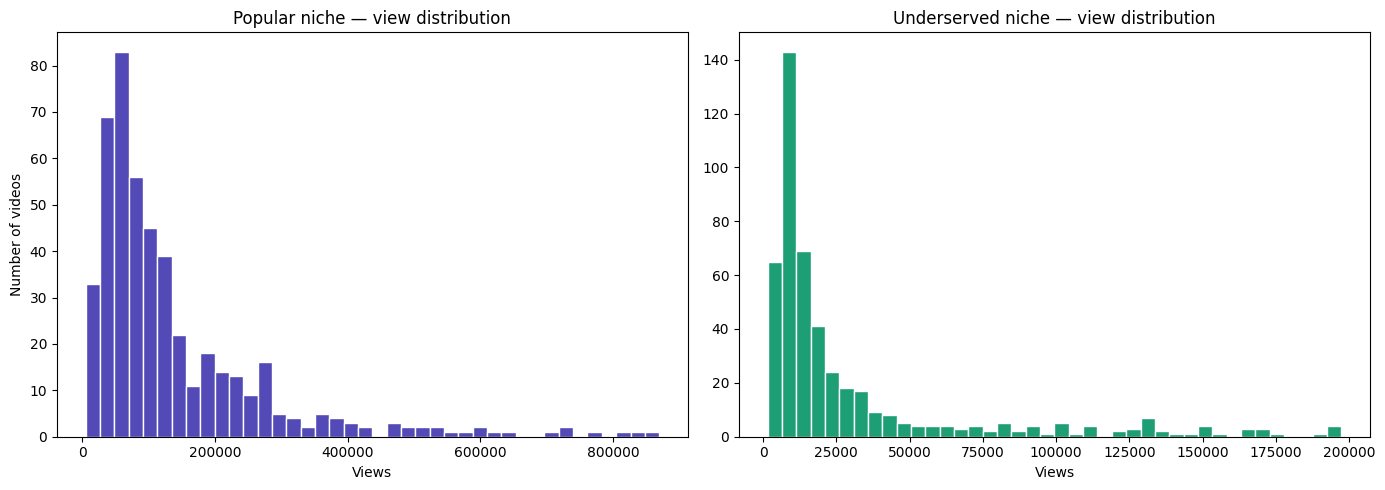

In [6]:
# Cell 6 — Visualise view distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    popular_df[popular_df["view_count"] < popular_df["view_count"].quantile(0.95)]["view_count"],
    bins=40, color="#534AB7", edgecolor="white"
)
axes[0].set_title("Popular niche — view distribution")
axes[0].set_xlabel("Views")
axes[0].set_ylabel("Number of videos")

axes[1].hist(
    underserved_df[underserved_df["view_count"] < underserved_df["view_count"].quantile(0.95)]["view_count"],
    bins=40, color="#1D9E75", edgecolor="white"
)
axes[1].set_title("Underserved niche — view distribution")
axes[1].set_xlabel("Views")

plt.tight_layout()
plt.savefig("../reports/niche_view_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Cell 7 — Save comparison to reports
comparison.to_csv("../data/processed/niche_comparison.csv", index=False)
print("\nNiche comparison saved to data/processed/niche_comparison.csv")
print(f"\nTotal API quota used: {collector.quota_used} units")


Niche comparison saved to data/processed/niche_comparison.csv

Total API quota used: 0 units
